# Analysis of image grouping using tSNE (2014)

###### Pretrained CNN + KPCA

In [1]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocess title embeddings for tSNE
###### r=0.9

In [ ]:
df_emb = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.image', sep='\t')
df_emb.head(5)

,img_id:token,img_emb:float_seq
0,0,0.014428207 -0.01609465 0.03294648 0.010992038...
1,1,0.013374746 -0.0040851366 0.017846484 0.009146...
2,3,0.025485406 0.044892143 0.06540884 0.07273897 ...
3,2,0.0927549 0.0003234906 0.0068842433 0.05643998...
4,4,0.026845569 -0.0059881625 0.06385405 -0.019091...


In [3]:
df_emb.rename(columns={"img_emb:float_seq": "emb", "img_id:token": "id"}, inplace=True)
df_emb["emb"] = df_emb["emb"].apply(lambda x: np.fromstring(x, dtype=np.float32, sep=' '))
df_emb.head(5)

,id,emb
0,0,"[0.014428207, -0.01609465, 0.03294648, 0.01099..."
1,1,"[0.013374746, -0.0040851366, 0.017846484, 0.00..."
2,3,"[0.025485406, 0.044892143, 0.06540884, 0.07273..."
3,2,"[0.0927549, 0.0003234906, 0.0068842433, 0.0564..."
4,4,"[0.026845569, -0.0059881625, 0.06385405, -0.01..."


In [ ]:
df_cat = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.item', sep='\t')
df_cat.head(5)

,item_id:token,title:token,price:float,brand:token,categories:token_seq,sales_type:token,sales_rank:float
0,0,Ghost Inc Glock Armorers Tool 3/32 Punch,9.99,Ghost,"'Sports & Outdoors', 'Hunting', 'Hunting & Fis...",Sports &amp; Outdoors,532941.0
1,1,5 LED Bicycle Rear Tail Red Bike Torch Laser B...,8.26,NaN,"'Lights & Reflectors', 'Sports & Outdoors', 'C...",Toys & Games,15617.0
2,3,Black Mountain Products Resistance Band Set wi...,32.99,Black Mountain,"'Accessories', 'Exercise Bands', 'Sports & Out...",Sports &amp; Outdoors,1010.0
3,2,Black Mountain Products Single Resistance Band...,10.49,Black Mountain,"'Accessories', 'Exercise Bands', 'Sports & Out...",Sports &amp; Outdoors,1010.0
4,4,Outers Universal 32-Piece Blow Molded Gun Clea...,21.99,Outers,"'Sports & Outdoors', 'Hunting', 'Gun Cleaning ...",Sports &amp; Outdoors,26457.0


In [6]:
df_cat = df_cat.rename(columns={"categories:token_seq": "cat", "item_id:token": "id"})
df_cat['cat'] = df_cat['cat'].apply(lambda x: [entry for entry in str(x).split(',')])
df_cat.drop(columns=['price:float', 'title:token', 'sales_rank:float', 'sales_type:token'], inplace=True)
df_cat.head(5)

,id,brand:token,cat
0,0,Ghost,"['Sports & Outdoors', 'Hunting', 'Hunting & ..."
1,1,NaN,"['Lights & Reflectors', 'Sports & Outdoors', ..."
2,3,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ..."
3,2,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ..."
4,4,Outers,"['Sports & Outdoors', 'Hunting', 'Gun Cleani..."


## 2. Create colour column

In [7]:
categories_2d = df_cat['cat'].tolist()

categories = []
for entry in categories_2d:
    for cat in entry:
        categories.append(cat)

categories = set(categories)

In [8]:
colour_dict = {cat: np.random.randint(0, 256, size=3) for cat in categories}

def rgb_mean(cat_list):
    arr = np.array([colour_dict[x] for x in cat_list])
    return arr.mean(axis=0)

In [9]:
df_cat['colour'] = df_cat['cat'].apply(rgb_mean)
df_cat.head(5)

,id,brand:token,cat,colour
0,0,Ghost,"['Sports & Outdoors', 'Hunting', 'Hunting & ...","[185.0, 166.8, 171.6]"
1,1,NaN,"['Lights & Reflectors', 'Sports & Outdoors', ...","[157.25, 181.0, 142.0]"
2,3,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ...","[181.0, 110.0, 76.5]"
3,2,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ...","[181.0, 110.0, 76.5]"
4,4,Outers,"['Sports & Outdoors', 'Hunting', 'Gun Cleani...","[194.0, 183.0, 173.6]"


## 3. Sample items and analise with tSNE

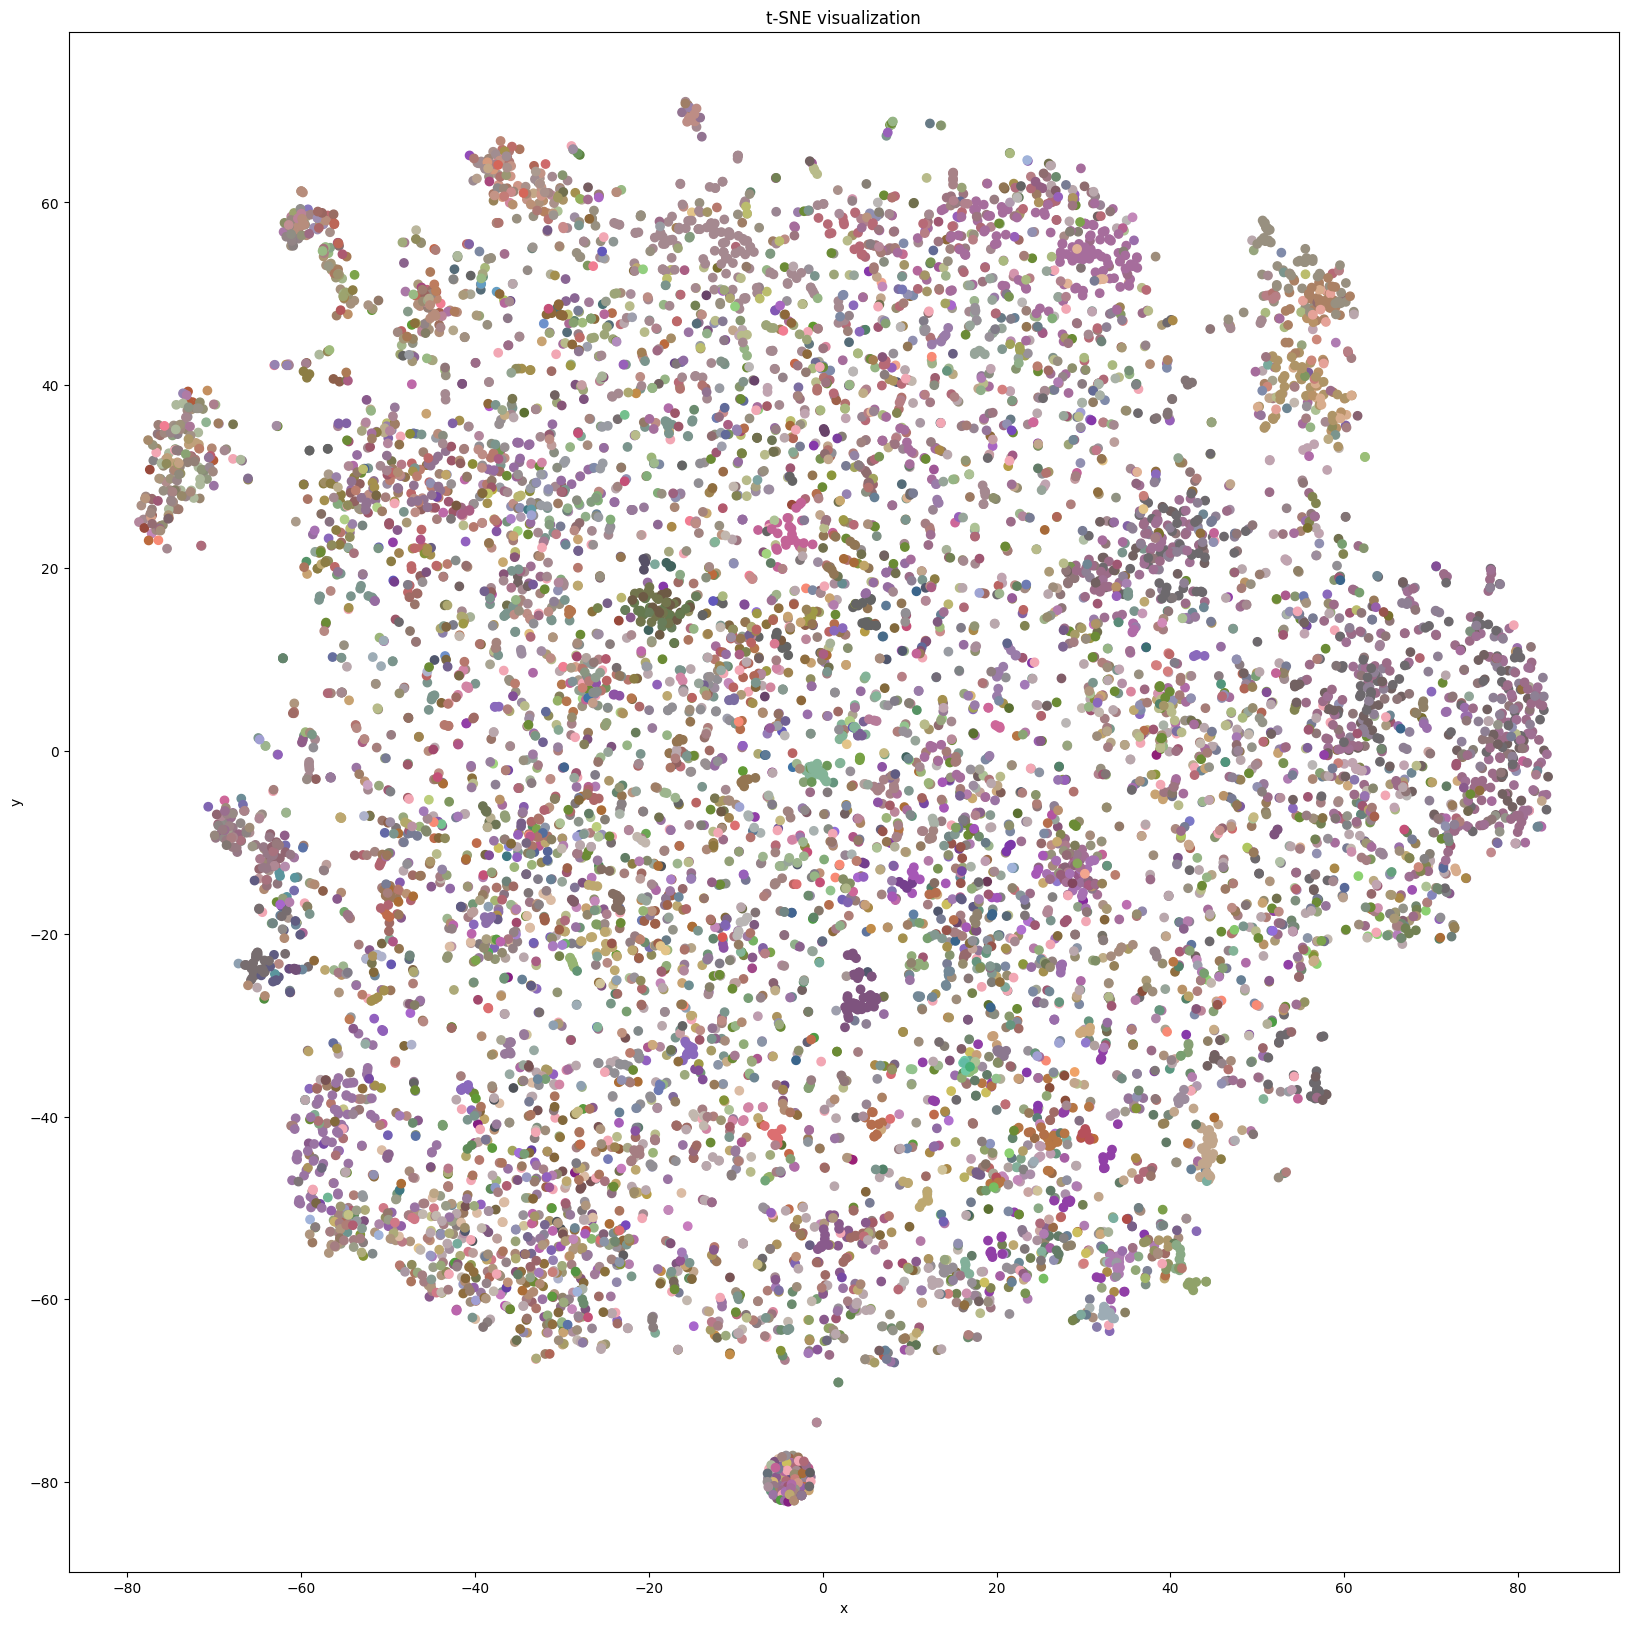

In [13]:
SAMPLE_SIZE = 10000

emb_series = df_emb[df_emb['emb'].notnull()]['emb']

X = np.vstack(emb_series.values)

rand_ind = np.random.choice(range(len(X)), SAMPLE_SIZE, replace=False)
X = X[rand_ind]

X_emb = TSNE(n_components=2, perplexity=32).fit_transform(X)
plt.figure(figsize=(20, 20))
plt.title(f't-SNE visualization')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(X_emb[:,0], X_emb[:,1], c=df_cat['colour'][rand_ind] / 255.0)
plt.show()